<a href="https://colab.research.google.com/github/cs24dse016-design/CSL701-CS43_Machine-Learning-Lab/blob/main/Experiments/MLExperiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name :-Khushi Harishchandra Pawar
Roll NO:- CS43

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from sklearn.ensemble import BaggingClassifier

# For reproducible results
np.random.seed(42)

In [3]:

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("First 5 records:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nDescriptive Statistics:")
display(df.describe())

First 5 records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

In [4]:
print("\n" + "="*60)
print("TASK 2: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Class count
class_counts = df["Outcome"].value_counts().sort_index()

print("\nClass Counts:")
print("Non-Diabetic (0):", class_counts[0])
print("Diabetic (1):", class_counts[1])

# Class percentage
class_percentage = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("\nClass Percentage:")
print("Non-Diabetic (0):", round(class_percentage[0], 2), "%")
print("Diabetic (1):", round(class_percentage[1], 2), "%")



TASK 2: EXPLORATORY DATA ANALYSIS

Class Counts:
Non-Diabetic (0): 500
Diabetic (1): 268

Class Percentage:
Non-Diabetic (0): 65.1 %
Diabetic (1): 34.9 %


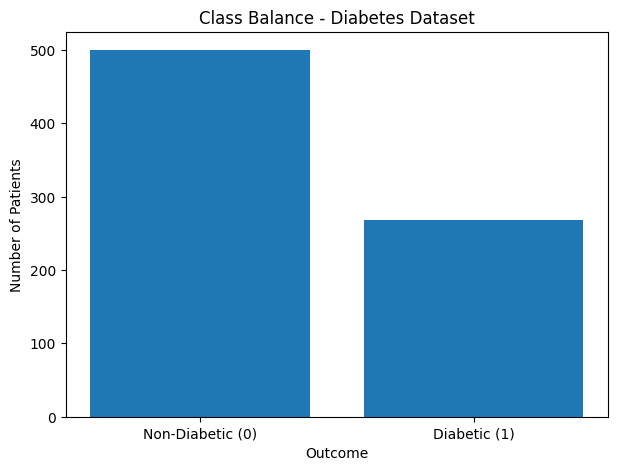

In [5]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Diabetic (0)", "Diabetic (1)"],
    [class_counts[0], class_counts[1]]
)

plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.title("Class Balance - Diabetes Dataset")
plt.show()


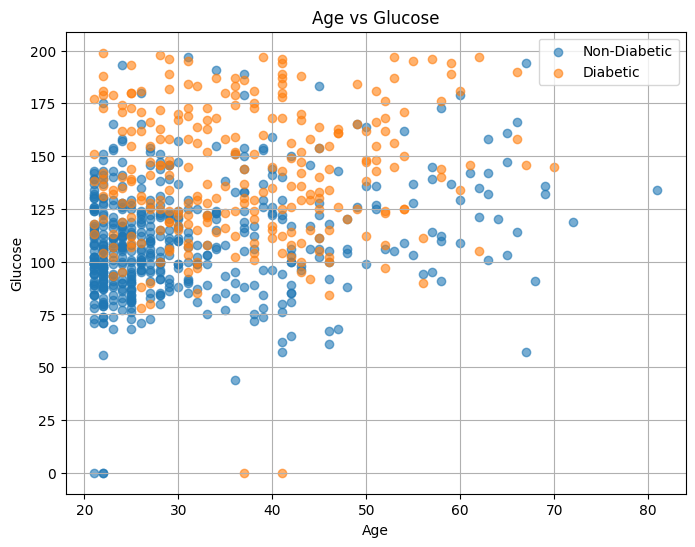

In [6]:
plt.figure(figsize=(8, 6))

for outcome in [0, 1]:
    subset = df[df["Outcome"] == outcome]

    plt.scatter(
        subset["Age"],
        subset["Glucose"],
        label="Non-Diabetic" if outcome == 0 else "Diabetic",
        alpha=0.6
    )

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Age vs Glucose")
plt.legend()
plt.grid(True)
plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [8]:
print("\n" + "="*60)
print("TASK 3: PREPROCESSING")
print("="*60)

# Features where 0 is physically impossible
invalid_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("\nNumber of zero values before replacement:")

for col in invalid_features:
    print(col, ":", (df[col] == 0).sum())


# Replace zero with NaN
df[invalid_features] = df[invalid_features].replace(0, np.nan)

print("\nMissing values after replacing 0 with NaN:")
print(df.isnull().sum())


# Median imputation
for col in invalid_features:
    df[col] = df[col].fillna(df[col].median())


print("\nMissing values after median imputation:")
print(df.isnull().sum())



TASK 3: PREPROCESSING

Number of zero values before replacement:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing values after replacing 0 with NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [9]:
print("\n" + "="*60)
print("TASK 4: TRAIN-TEST SPLIT")
print("="*60)

# Feature matrix and target
X = df.iloc[:, :8]
y = df.iloc[:, 8]

print("X shape:", X.shape)
print("y shape:", y.shape)

# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)



TASK 4: TRAIN-TEST SPLIT
X shape: (768, 8)
y shape: (768,)

Training data shape: (614, 8)
Testing data shape: (154, 8)

Training class distribution:
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [11]:
print("\n" + "="*60)
print("TASK 5: CUSTOM BOOTSTRAP SAMPLING")
print("="*60)


def get_bootstrap_sample(X, y):
    """
    Creates a bootstrap sample using sampling with replacement.
    """

    n_samples = len(X)

    # Random indices with replacement
    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    # Create bootstrap datasets
    X_bootstrap = X.iloc[indices].reset_index(drop=True)
    y_bootstrap = y.iloc[indices].reset_index(drop=True)

    return X_bootstrap, y_bootstrap, indices
    # Demonstrate bootstrap sampling
X_boot, y_boot, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)

print("Original training samples:", len(X_train))
print("Bootstrap samples:", len(X_boot))

print("\nFirst 20 bootstrap indices:")
print(bootstrap_indices[:20])




TASK 5: CUSTOM BOOTSTRAP SAMPLING
Original training samples: 614
Bootstrap samples: 614

First 20 bootstrap indices:
[102 435 270 106  71  20 121 466 214 330 458  87 372  99 130 308 343 491
 413 385]


In [12]:
# Duplicate indices
unique_indices = np.unique(bootstrap_indices)

print("\nUnique samples selected:", len(unique_indices))

print("Duplicate selections:",
      len(bootstrap_indices) - len(unique_indices))


Unique samples selected: 377
Duplicate selections: 237


In [13]:
# OOB indices
all_indices = set(range(len(X_train)))
selected_indices = set(bootstrap_indices)

oob_indices = sorted(list(all_indices - selected_indices))

print("OOB samples:", len(oob_indices))

print("\nSome OOB indices:")
print(oob_indices[:20])

OOB samples: 237

Some OOB indices:
[2, 3, 5, 6, 10, 12, 23, 25, 29, 30, 31, 33, 39, 43, 44, 49, 51, 54, 55, 56]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [14]:
print("\n" + "="*60)
print("TASK 6: GROWING BAGGING ENSEMBLE")
print("="*60)

# Number of trees
B = 50

# Empty list for models
ensemble = []

for i in range(B):

    # Generate bootstrap sample
    X_bootstrap, y_bootstrap, indices = get_bootstrap_sample(
        X_train,
        y_train
    )

    # Create fully grown Decision Tree
    tree = DecisionTreeClassifier(
        max_depth=None,
        random_state=100 + i
    )

    # Train tree
    tree.fit(X_bootstrap, y_bootstrap)

    # Store tree
    ensemble.append(tree)


print("Number of decision trees in ensemble:", len(ensemble))


TASK 6: GROWING BAGGING ENSEMBLE
Number of decision trees in ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [17]:
print("\n" + "="*60)
print("TASK 7: CUSTOM MAJORITY VOTING")
print("="*60)


def custom_bagging_predict(ensemble, X_test):
    """
    Predict using majority voting.
    """

    # Predictions from every tree
    all_predictions = np.array([
        model.predict(X_test)
        for model in ensemble
    ])

    # Majority voting
    final_predictions = []

    for i in range(all_predictions.shape[1]):

        votes = all_predictions[:, i]

        # Count votes for class 0 and class 1
        count_0 = np.sum(votes == 0)
        count_1 = np.sum(votes == 1)

        if count_1 > count_0:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


# Make predictions
y_pred_bagging = custom_bagging_predict(
    ensemble,
    X_test
)

print("First 20 Bagging predictions:")
print(y_pred_bagging[:20])


TASK 7: CUSTOM MAJORITY VOTING
First 20 Bagging predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [18]:
print("\n" + "="*60)
print("TASK 8: SINGLE TREE VS BAGGING")
print("="*60)


TASK 8: SINGLE TREE VS BAGGING


In [ ]:
# ------------------------------------------------------------
# Single Decision Tree
# ------------------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

y_pred_tree = single_tree.predict(X_test)



TASK 8: SINGLE TREE VS BAGGING

 Single Decision Tree
----------------------------------------
Accuracy : 0.6818
Precision: 0.5532
Recall   : 0.4815
F1-Score : 0.5149

 Custom Bagging
----------------------------------------
Accuracy : 0.7468
Precision: 0.6744
Recall   : 0.537
F1-Score : 0.5979

Confusion Matrix - Single Decision Tree:
[[79 21]
 [28 26]]


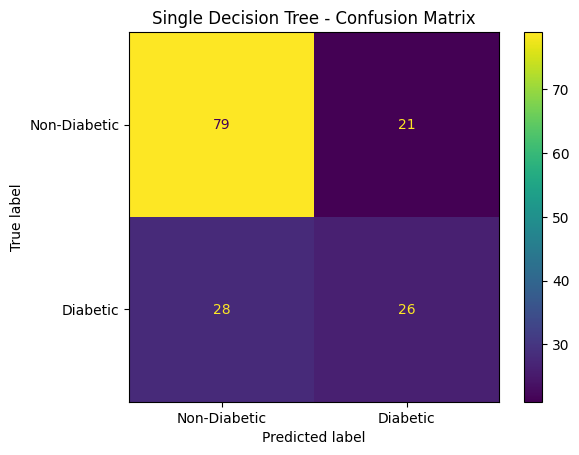


Confusion Matrix - Custom Bagging:
[[86 14]
 [25 29]]


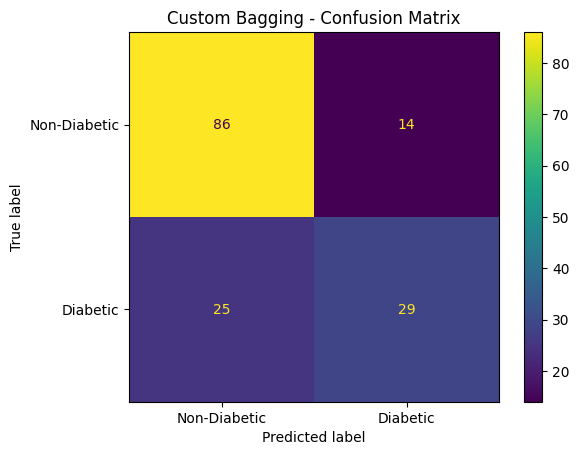


Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Single Decision Tree,0.6818,0.5532,0.4815,0.5149
1,Custom Bagging,0.7468,0.6744,0.5370,0.5979


In [26]:
print("\n" + "="*60)
print("TASK 8: SINGLE TREE VS BAGGING")
print("="*60)

# ------------------------------------------------------------
# Single Decision Tree
# ------------------------------------------------------------

single_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

single_tree.fit(X_train, y_train)

y_pred_tree = single_tree.predict(X_test)


# ------------------------------------------------------------
# Performance function
# ------------------------------------------------------------

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n", name)
    print("-" * 40)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

    return accuracy, precision, recall, f1


# Evaluate Single Tree
tree_metrics = evaluate_model(
    "Single Decision Tree",
    y_test,
    y_pred_tree
)


# Evaluate Bagging
bagging_metrics = evaluate_model(
    "Custom Bagging",
    y_test,
    y_pred_bagging
)


# ------------------------------------------------------------
# Confusion Matrix - Single Tree
# ------------------------------------------------------------

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("\nConfusion Matrix - Single Decision Tree:")
print(cm_tree)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Single Decision Tree - Confusion Matrix")
plt.show()


# ------------------------------------------------------------
# Confusion Matrix - Custom Bagging
# ------------------------------------------------------------

cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)

print("\nConfusion Matrix - Custom Bagging:")
print(cm_bagging)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bagging,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Custom Bagging - Confusion Matrix")
plt.show()


# ============================================================
# PERFORMANCE COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Custom Bagging"
    ],

    "Accuracy": [
        tree_metrics[0],
        bagging_metrics[0]
    ],

    "Precision": [
        tree_metrics[1],
        bagging_metrics[1]
    ],

    "Recall": [
        tree_metrics[2],
        bagging_metrics[2]
    ],

    "F1-Score": [
        tree_metrics[3],
        bagging_metrics[3]
    ]
})

print("\nPerformance Comparison:")
display(comparison.round(4))


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.


TASK 9: ROC-AUC ANALYSIS
Single Decision Tree AUC: 0.6357
Custom Bagging AUC: 0.8087


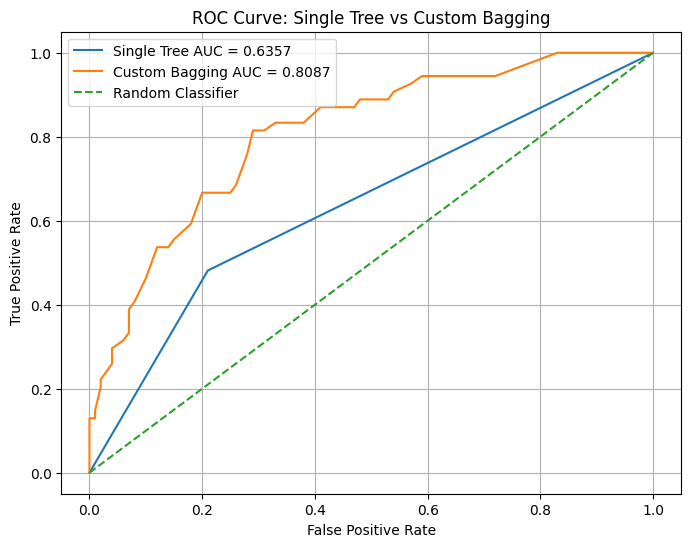

In [27]:
print("\n" + "="*60)
print("TASK 9: ROC-AUC ANALYSIS")
print("="*60)


# ------------------------------------------------------------
# Single tree probabilities
# ------------------------------------------------------------

y_prob_tree = single_tree.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# Custom Bagging probabilities
# ------------------------------------------------------------

all_probabilities = np.array([
    model.predict_proba(X_test)[:, 1]
    for model in ensemble
])

# Average probabilities
y_prob_bagging = np.mean(
    all_probabilities,
    axis=0
)


# ------------------------------------------------------------
# Calculate ROC and AUC
# ------------------------------------------------------------

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

fpr_bagging, tpr_bagging, _ = roc_curve(
    y_test,
    y_prob_bagging
)

auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

auc_bagging = roc_auc_score(
    y_test,
    y_prob_bagging
)


print("Single Decision Tree AUC:",
      round(auc_tree, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))


# ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Single Tree AUC = {auc_tree:.4f}"
)

plt.plot(
    fpr_bagging,
    tpr_bagging,
    label=f"Custom Bagging AUC = {auc_bagging:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Single Tree vs Custom Bagging")
plt.legend()
plt.grid(True)
plt.show()

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.


TASK 10: SCIKIT-LEARN BAGGING CLASSIFIER
Scikit-learn Bagging Accuracy: 0.7338

Scikit-learn Bagging Confusion Matrix:
[[85 15]
 [26 28]]


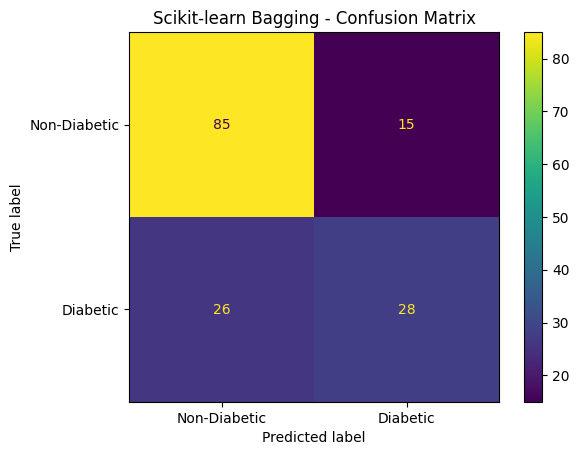


FINAL MODEL COMPARISON:


,Model,Accuracy,Precision,Recall,F1-Score
0,Single Decision Tree,0.6818,0.5532,0.4815,0.5149
1,Custom Bagging,0.7468,0.6744,0.5370,0.5979
2,Scikit-learn Bagging,0.7338,0.6512,0.5185,0.5773



FINAL SUMMARY
Dataset Shape: (768, 9)
Training Samples: 614
Testing Samples: 154
Number of Trees: 50

Single Decision Tree AUC: 0.6357
Custom Bagging AUC: 0.8087

Custom Bagging Accuracy: 0.7468
Scikit-learn Bagging Accuracy: 0.7338

Experiment completed successfully.


In [28]:
print("\n" + "="*60)
print("TASK 10: SCIKIT-LEARN BAGGING CLASSIFIER")
print("="*60)


# Create base Decision Tree
base_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)


# ------------------------------------------------------------
# Built-in BaggingClassifier
# ------------------------------------------------------------

# Current Scikit-learn uses "estimator="
sklearn_bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    bootstrap=True,
    random_state=42
)

# Train
sklearn_bagging.fit(
    X_train,
    y_train
)

# Predict
y_pred_sklearn = sklearn_bagging.predict(
    X_test
)


# Accuracy
sklearn_accuracy = accuracy_score(
    y_test,
    y_pred_sklearn
)

print("Scikit-learn Bagging Accuracy:",
      round(sklearn_accuracy, 4))


# Confusion Matrix
cm_sklearn = confusion_matrix(
    y_test,
    y_pred_sklearn
)

print("\nScikit-learn Bagging Confusion Matrix:")
print(cm_sklearn)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sklearn,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Scikit-learn Bagging - Confusion Matrix")
plt.show()


# ============================================================
# FINAL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({

    "Model": [
        "Single Decision Tree",
        "Custom Bagging",
        "Scikit-learn Bagging"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_bagging),
        accuracy_score(y_test, y_pred_sklearn)
    ],

    "Precision": [
        precision_score(y_test, y_pred_tree, zero_division=0),
        precision_score(y_test, y_pred_bagging, zero_division=0),
        precision_score(y_test, y_pred_sklearn, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_pred_tree, zero_division=0),
        recall_score(y_test, y_pred_bagging, zero_division=0),
        recall_score(y_test, y_pred_sklearn, zero_division=0)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_tree, zero_division=0),
        f1_score(y_test, y_pred_bagging, zero_division=0),
        f1_score(y_test, y_pred_sklearn, zero_division=0)
    ]
})


print("\nFINAL MODEL COMPARISON:")
display(final_comparison.round(4))


# ============================================================
# FINAL OUTPUT SUMMARY
# ============================================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("Dataset Shape:", df.shape)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Number of Trees:", B)

print("\nSingle Decision Tree AUC:",
      round(auc_tree, 4))

print("Custom Bagging AUC:",
      round(auc_bagging, 4))

print("\nCustom Bagging Accuracy:",
      round(accuracy_score(y_test, y_pred_bagging), 4))

print("Scikit-learn Bagging Accuracy:",
      round(sklearn_accuracy, 4))

print("\nExperiment completed successfully.")

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?